In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import math as m

In [ ]:
import os
current_dir = os.getcwd()
print(current_dir)

/content


In [ ]:
import warnings
warnings.filterwarnings('ignore')

## ПРИМЕР

По результатам контрольной проверки налоговыми службами 400 бизнес-структур, у 140 из них в налоговых декларациях не полностью указаны доходы, подлежащие налогообложению. Определите в генеральной совокупности (по всему району) долю бизнес-структур, скрывших часть доходов от уплаты налогов, с вероятностью 0,954.(Z=1.96))

![image.png](attachment:image.png)

In [ ]:
m = 140
n = 400
Z = 1.96
p = m / n
p

0.35

In [ ]:
p - H, p + H

In [ ]:
H = Z * math.sqrt(p * (1 - p) / n)
H

0.04674302086943033

In [ ]:
p - H

0.30325697913056965

In [ ]:
p + H

0.3967430208694303

### Ответ:
Доля бизнес-структур, скрывших часть доходов от уплаты налогов с вероятностью 0,954 равна 35±5%

## Задача 1

Вам поручено провести исследование по вопросу вывода нового продукта на рынок. В ходе исследования были опрошены 1200 человек (число_опрошенных = 1200). 25% из них заинтересовались новым продуктом (доля_ответов(р) = 0.25).

Рассчитайте показатель ошибки выборочного расчёта (или по другому - предельная ошибка “Н”) при условии доверительного уровня Z, равного 95%. И выведите ответ в формате интервала p - Н и p + Н. Ответ дайте в процентах и с округлением до второго знака.

Данные с результатами исследования находятся в файле data.csv с полями:

в первом столбце – число_опрошенных
во втором столбце – доля_ответов
в третьем столбце – доверительный_уровень
Разделитель столбцов – точка с запятой, десятичный разделитель – запятая.

In [ ]:
PATH_OUT = r'C:\Users\Dell\Desktop\MyPython\Yandex.Practica\ПРЕДЛОЖЕНИЯ\Школьники\Работа_над_материалами\Тема_4'

In [ ]:
df = pd.read_csv('zad_1.csv',sep=';', encoding='cp1251', skipinitialspace=True, decimal=',')
df = df.dropna()
df.head(3)
n = df.iloc[0, 0]
p = df.iloc[0, 1]
Z = df.iloc[0, 2]
H = Z * m.sqrt(p * (1 - p) / n)
print(round((p - H) * 100, 2), round((p + H) * 100, 2))

22.55 27.45


## Задача 2

На стоянке магазина подержанных автомобилей стоит 1200 машин. Провели осмотр 200 машин и зафиксировали пробег (в тыс км).
Требуется рассчитать интервал истинной генеральной доли автомобилей с пробегом более 140. при условии доверительного уровня Z, равного 95%.
Расчёт произвести в процентах и с округлением до второго знака. Вывести на экран в виде p - Н и p + Н

Данные с результатами исследования находятся в файле data.csv с одним полем:

пробег
Разделитель столбцов – точка с запятой, десятичный разделитель – запятая.

In [ ]:
df = pd.read_csv('auto.csv', sep=',', encoding='cp1251', skipinitialspace=True)
count = sum(1 if x > 140 else 0 for x in df['пробег'])
n = 200
N = 1200
p = count / n
Z = 1.96
H = Z * m.sqrt(p * (1 - p) / n)
print(round((p - H) * 100, 2), round((p + H) * 100, 2))

47.6 61.4


![image.png](attachment:image.png)

### Дополнительно

## Задача 3

Производитель контролирует вес шоколадки Полёт. Вес в среднем должен быть 70 грамм. Какую выборку нужно отобрать, чтобы с доверительным уровнем Z, равным 95%, обеспечить предельную погрешность среднего Н 1 грамм. Данные об измерениях веса вес_шоколадки представлены в файле.


На этапе анализа данных выяснилось, что есть "супервыбросы" в данных. Перед проведением расчёта от них необходимо избавиться.


Окончательный результат вывести в виде числа, округлённого до целого.

Данные с результатами исследования разных шоколадок находятся в файле data.csv с полями:

в первом столбце – вес_шоколадки
во втором столбце – название
Разделитель столбцов – точка с запятой, десятичный разделитель – запятая

Формат ввода

In [ ]:
df = pd.read_csv('choco.csv',sep=';', encoding='cp1251', skipinitialspace=True)
df = df[(df['вес_шоколадки'] > 50) & (df['вес_шоколадки'] < 150) & (df['название'] == 'Полёт')]
mean = df['вес_шоколадки'].mean()
std = 0
for x in df['вес_шоколадки']:
  std += (x - mean) ** 2
std = m.sqrt(std / (len(df['вес_шоколадки']) - 1))
z = 1.96
H = 1
n = (z * std / H) ** 2
print(round(n))

,вес_шоколадки
count,98.000000
mean,69.897959
std,5.308017
min,57.000000
25%,67.000000
50%,70.000000
75%,73.000000
max,86.000000


## Задача 4

Необходимо рассчитать объем выборки для проведения опроса населения по вопросу повышения пенсионного возраста, в зависимости от предельной ошибки Н. Соотношение за/против населения по данному вопросу - не известно. Доверительный уровень Z принимаем 95%. H изменяется от 0.01 до 0.1 с шагом 0.01.

Результат вывести в виде таблицы DataFrame из двух столбцов.
Название первого столбца: допустимая_ошибка: выводим предельную ошибку Н в процентах и в целочисленном виде.
Название второго столбца размер_выборки: выводим значение посчитанного объёма выборки n в целочисленном виде.

цикл, данные в самой задаче

In [ ]:
Z = 1.96
p = 0.5
df = pd.DataFrame(columns=['допустимая_ошибка', 'размер_выборки'])
array = np.arange(0.01, 0.1, 0.01)
array = [int(round(x * 100)) for x in array]
df['допустимая_ошибка'] = array
df['размер_выборки'] = [int((Z * p / (H / 100)) ** 2 + 0.0000001) for H in df['допустимая_ошибка']]
df

,допустимая_ошибка,размер_выборки
0,1,9604
1,2,2401
2,3,1067
3,4,600
4,5,384
5,6,266
6,7,196
7,8,150
8,9,118


## Задача 5

За смену выпускается 8000 шоколадок. Необходимо:

1) определить предельную ошибку Н для шоколадок с весом более или равным 100 грамм. Результат округлить до третьего знака

2) Рассчитать, сколько нужно проконтролировать шоколадок, чтобы улучшить оценку допустимой ошибки (посчитанную в п.1) в 5 раз. Результат округлить до целого.

Доверительный уровень Z принимаем 95%. Вывод представить в виде пары чисел через запятую: результат пункта 1, результат пункта 2

Данные с результатами исследования находятся в файле data.csv с одним полем вес_шоколадки, десятичный разделитель – запятая.

In [ ]:
df = pd.read_csv('cake.csv',sep=',', encoding='cp1251', skipinitialspace=True)
count = sum(1 if x >= 100 else 0 for x in df['вес_шоколадки'])
n = 198
N = 8000
p = count / n
Z = 1.96
H = round(Z * m.sqrt(p * (1 - p) / n - 0.00001), 3)
H1 = round(H / 5, 3)
n = (Z * m.sqrt(p * (1 - p)) / H1) ** 2
n_new = N * n / (N + n - 1)
print(H, round(n_new), sep=' , ')


0.066 , 3150


In [ ]:
df.shape

(198, 1)

## Задача 6

In [ ]:
PATH_OUT = r'C:\Users\Dell\Desktop\MyPython\Yandex.Practica\ПРЕДЛОЖЕНИЯ\Школьники\Работа_над_материалами\Тема_4'

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data.csv')
df.columns = df.columns.str.lower().str.replace(' ', '_')
category = input()
df = df[df['покупательская_активность'] == category]
df.reset_index(drop=True, inplace=True)
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
sns.histplot(data=df, x='выручка_от_клиента_текущий_месяц', bins=30, kde=True, ax=axes[0])
axes[0].set_title('')
axes[0].set_xlabel('')
axes[0].set_ylabel('')
sns.boxplot(data=df, x='выручка_от_клиента_текущий_месяц', ax=axes[1])
axes[1].set_title('')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
fig.suptitle('Гистограмма и ящик с усами для количественных данных')
plt.savefig('target_4_6.png')

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Dell\\Desktop\\MyPython\\Yandex.Practica\\ПРЕДЛОЖЕНИЯ\\Школьники\\Работа_над_материалами\\Тема_4\\graph.csv'

In [ ]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.head(3)

,покупательская_активность,выручка_от_клиента_текущий_месяц
0,Снизилась,4425
1,Снизилась,4472
2,Снизилась,4826


Снизилась


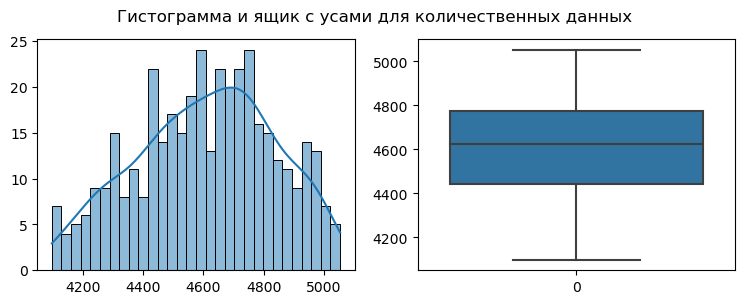